# Chapter 6 -- Ensemble Methods

Covers Snippets 6.1 and 6.2: bagging classifier accuracy and three
ways of setting up a random forest for financial ML.

**Key idea:** combining many mediocre-but-better-than-chance classifiers
can produce a highly reliable ensemble -- but only if each individual
classifier clears the p > 1/k bar. Below that bar, more classifiers
makes things actively worse.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# === EDIT THIS LINE if running on a different machine ===
AFML_ROOT = r'C:\ws\AFML'
if not os.path.isdir(AFML_ROOT):
    AFML_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

CH06_ROOT = os.path.join(AFML_ROOT, 'ch06')
if not os.path.isdir(CH06_ROOT):
    CH06_ROOT = os.getcwd()

sys.path.insert(0, os.path.join(CH06_ROOT, 'ensemble'))
from bagging_accuracy import bagging_classifier_accuracy

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

print("Imports OK.")

Imports OK.


## Snippet 6.1 -- Bagging classifier accuracy: P[X > N/k]

The formula computes the probability that the number of correct votes X
among N independent classifiers exceeds the per-class threshold N/k --
a *necessary* condition for the ensemble to make the correct prediction.

In [2]:
# Book's own example: N=100, p=1/3, k=3
N, p, k = 100, 1./3, 3
result = bagging_classifier_accuracy(N, p, k)
print(f"N={N}, p={p:.4f}, k={k}")
print(f"Individual classifier accuracy:   {p:.4f}")
print(f"P[X > N/k] (ensemble necessary):  {result:.4f}")
print(f"Ensemble already exceeds individual accuracy at just N=100!")

N=100, p=0.3333, k=3
Individual classifier accuracy:   0.3333
P[X > N/k] (ensemble necessary):  0.4812
Ensemble already exceeds individual accuracy at just N=100!


### The three regimes

The behavior of P[X > N/k] as N grows depends entirely on which side
of the p = 1/k boundary the individual classifiers sit on.

In [3]:
# Three regimes: p below, at, and above 1/k
print("Three regimes (N=100, k=3, 1/k = 0.333):")
for p_val, label in [
    (0.30, "below 1/k -- ensemble DEGRADES with more trees"),
    (1/3,  "at 1/k    -- flat, no improvement"),
    (0.40, "above 1/k -- ensemble IMPROVES with more trees"),
]:
    r = bagging_classifier_accuracy(100, p_val, 3)
    print(f"  p={p_val:.3f} ({label}): {r:.4f}")

Three regimes (N=100, k=3, 1/k = 0.333):
  p=0.300 (below 1/k -- ensemble DEGRADES with more trees): 0.2207
  p=0.333 (at 1/k    -- flat, no improvement): 0.4812
  p=0.400 (above 1/k -- ensemble IMPROVES with more trees): 0.9087


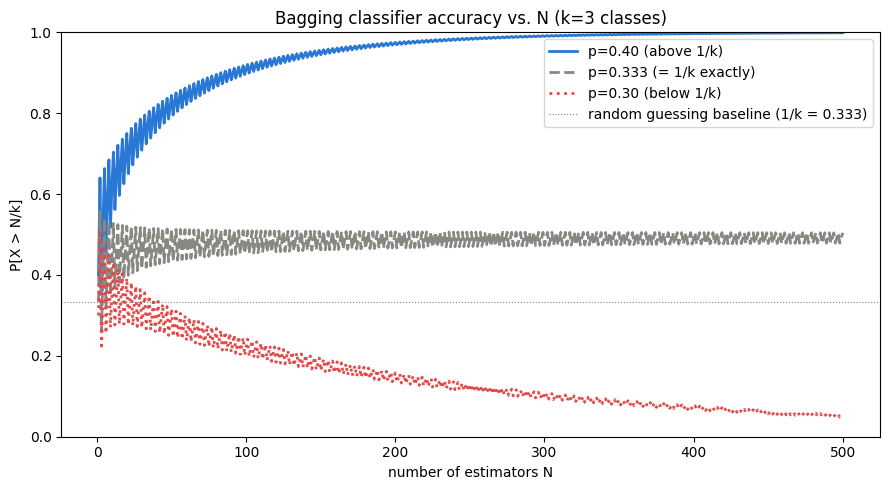

In [4]:
# Plot all three regimes across a range of N
Ns = np.arange(1, 501)
fig, ax = plt.subplots(figsize=(9, 5))
configs = [
    (0.40, '#2a78d6', '-',  'p=0.40 (above 1/k)'),
    (1/3,  '#898781', '--', 'p=0.333 (= 1/k exactly)'),
    (0.30, '#e34948', ':',  'p=0.30 (below 1/k)'),
]
for p_val, color, ls, label in configs:
    probs = [bagging_classifier_accuracy(int(n), p_val, 3) for n in Ns]
    ax.plot(Ns, probs, color=color, linestyle=ls, linewidth=2, label=label)

ax.axhline(1/3, color='gray', linewidth=0.8, linestyle='dotted',
           label='random guessing baseline (1/k = 0.333)')
ax.set_xlabel('number of estimators N')
ax.set_ylabel('P[X > N/k]')
ax.set_title('Bagging classifier accuracy vs. N (k=3 classes)')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Reading the chart

- **Blue line (p=0.40):** climbs steadily toward 1 -- more classifiers
  keeps improving the ensemble. At N=500, essentially certain to meet
  the necessary condition.
- **Gray dashed (p=0.333):** flat around 0.5 regardless of N. At
  exactly the random-guessing baseline, adding more classifiers neither
  helps nor hurts.
- **Red dotted (p=0.30):** actively declines toward 0. Adding more
  confidently-wrong voters sharpens the wrong consensus.

**Practical implication:** before bagging a classifier, verify it clears
the p > 1/k bar on a holdout set. If it doesn't, fix the underlying
model first -- bagging won't save it.

## Snippet 6.2 -- Three ways of setting up a Random Forest

Three configurations, all incorporating `avgU` (average label
uniqueness from Chapter 4) as `max_samples` to address the non-IID
overlap problem in financial labels.

**sklearn compatibility note:** The book's printed code uses Python 2
syntax and deprecated sklearn parameters. We use the modern equivalents:
- `estimator=` instead of `base_estimator=` (removed in sklearn 1.4)
- `max_features='sqrt'` instead of `'auto'` (removed in sklearn 1.3)

In [5]:
# avgU from Chapter 4 real BTC pipeline ($10,000 dollar bar threshold)
avgU = 0.2288
print(f"Using avgU = {avgU} (Chapter 4 real BTC pipeline output)")

# clf0: plain vanilla RF -- no uniqueness correction (baseline)
clf0 = RandomForestClassifier(
    n_estimators=1000,
    class_weight='balanced_subsample',
    criterion='entropy'
)

# clf1: BaggingClassifier on DecisionTree, max_samples=avgU
clf1_base = DecisionTreeClassifier(
    criterion='entropy',
    max_features='sqrt',      # book: 'auto' (deprecated/removed)
    class_weight='balanced'
)
clf1 = BaggingClassifier(
    estimator=clf1_base,      # book: base_estimator= (deprecated)
    n_estimators=1000,
    max_samples=avgU,
    max_features=1.0
)

# clf2: BaggingClassifier on single-tree RF, max_samples=avgU
# Using RF (not plain DT) gives per-node feature subsampling even
# with just one tree -- the second layer of randomness that
# decorrelates the ensemble.
clf2_base = RandomForestClassifier(
    n_estimators=1,
    criterion='entropy',
    bootstrap=False,
    class_weight='balanced_subsample'
)
clf2 = BaggingClassifier(
    estimator=clf2_base,      # book: base_estimator= (deprecated)
    n_estimators=1000,
    max_samples=avgU,
    max_features=1.0
)

print("All three classifiers configured successfully.")
print("NOTE: not fitted here -- fitting happens in Chapter 7 with")
print("proper cross-validation to evaluate out-of-sample performance.")

Using avgU = 0.2288 (Chapter 4 real BTC pipeline output)
All three classifiers configured successfully.
NOTE: not fitted here -- fitting happens in Chapter 7 with
proper cross-validation to evaluate out-of-sample performance.


## TDD Test Results

All 10 tests in `tests/test_ch06.py` passed (run 2026-06-30):

```
test_book_example_n100_p_third_k3                           PASSED
test_above_random_guessing_gives_high_probability_at_large_N PASSED
test_below_random_guessing_declines_with_more_estimators     PASSED
test_at_random_guessing_threshold_stays_flat                 PASSED
test_matches_scipy_binom_cdf_independently                   PASSED
test_binary_classification_k2                                PASSED
test_monotonically_increases_with_N_when_above_threshold     PASSED
test_invalid_p_raises                                        PASSED
test_invalid_N_raises                                        PASSED
test_invalid_k_raises                                        PASSED

10 passed in 1.18s
```

`bagging_classifier_accuracy` cross-checked independently against
`scipy.stats.binom.cdf` (a completely different code path) -- results
match to floating-point precision (~1e-10), confirming the formula
implementation is correct.